Yehia Mohamad Kamal

AirBnB listings in Paris analysis to determine the impact of recent regulations

In [79]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('Listings.csv', encoding_errors='replace')

C:\Users\yehia\AppData\Local\Temp\ipykernel_10936\3638885617.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Listings.csv', encoding_errors='replace')


In [7]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [11]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÂ² Paris (Sacre CÅ“ur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [15]:
df.select_dtypes(include='object').head(2).T

,0,1
name,"Beautiful Flat in le Village Montmartre, Paris",39 mÂ² Paris (Sacre CÅ“ur)
host_since,2011-12-03,2013-11-29
host_location,"Paris, Ile-de-France, France","Paris, Ile-de-France, France"
host_response_time,NaN,NaN
host_is_superhost,f,f
host_has_profile_pic,t,t
host_identity_verified,f,t
neighbourhood,Buttes-Montmartre,Buttes-Montmartre
district,NaN,NaN
city,Paris,Paris


In [25]:
df['host_since'] = df['host_since'].astype('datetime64[ns]')

In [28]:
df['host_since'].head()

0   2011-12-03
1   2013-11-29
2   2014-07-31
3   2013-12-17
4   2014-12-14
Name: host_since, dtype: datetime64[ns]

In [32]:
paris_df = df.loc[df['city'] == 'Paris', ['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]
paris_df.head()

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


In [34]:
paris_df.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [100]:
paris_df[['accommodates', 'price']].agg(['min', 'max', 'mean'])

,accommodates,price
min,0.000000,0.000000
max,16.000000,12000.000000
mean,3.037997,113.096445


In [ ]:
paris_listings_neighbourhood = paris_df.groupby('neighbourhood')['price'].mean().sort_values().reset_index(name = 'average_price')
paris_listings_neighbourhood

,neighbourhood,average_price
0,Menilmontant,74.942257
1,Buttes-Chaumont,82.690182
2,Buttes-Montmartre,87.209479
3,Reuilly,89.058402
4,Popincourt,90.559459
5,Gobelins,98.110184
6,Observatoire,101.866801
7,Batignolles-Monceau,102.612702
8,Enclos-St-Laurent,102.967156
9,Vaugirard,106.831330


In [64]:
most_expensive_neighbourhood = paris_listings_neighbourhood.iloc[-1]['neighbourhood']
most_expensive_neighbourhood

'Elysee'

In [70]:
paris_listings_accomodations = paris_df[paris_df['neighbourhood'] == most_expensive_neighbourhood].groupby('accommodates')['price'].mean().sort_values().reset_index(name = 'average_price')
paris_listings_accomodations

,accommodates,average_price
0,0,0.000000
1,1,79.522222
2,3,152.828767
3,2,155.103352
4,4,212.096070
5,5,328.817073
6,6,355.508571
7,8,405.518519
8,7,411.538462
9,9,440.272727


In [76]:
paris_listings_over_time = paris_df.groupby(paris_df['host_since'].dt.year).agg(
    average_price = ('price', 'mean'),
    hosts_count = ('host_since', 'count')
)
paris_listings_over_time

,average_price,hosts_count
host_since,,
2008.0,77.750000,4
2009.0,159.641509,106
2010.0,125.031250,416
2011.0,124.828230,1339
2012.0,111.578615,4592
2013.0,107.096414,8142
2014.0,100.253800,10922
2015.0,103.646250,12147
2016.0,114.159847,8871


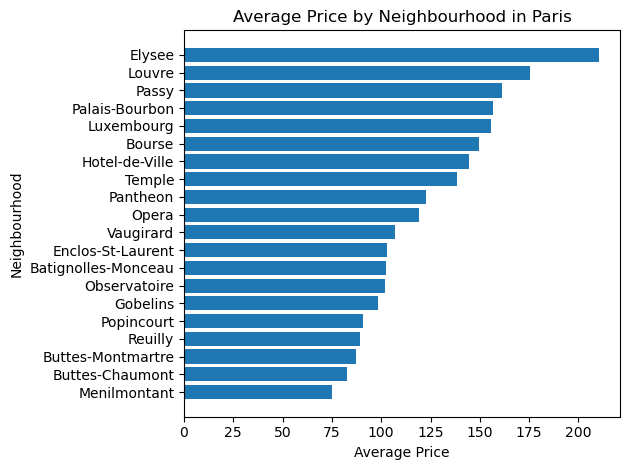

In [90]:
fig, ax = plt.subplots()
ax.barh(paris_listings_neighbourhood['neighbourhood'], paris_listings_neighbourhood['average_price'])
ax.set_xlabel('Average Price')
ax.set_ylabel('Neighbourhood')
ax.set_title('Average Price by Neighbourhood in Paris')
plt.tight_layout()
plt.show()

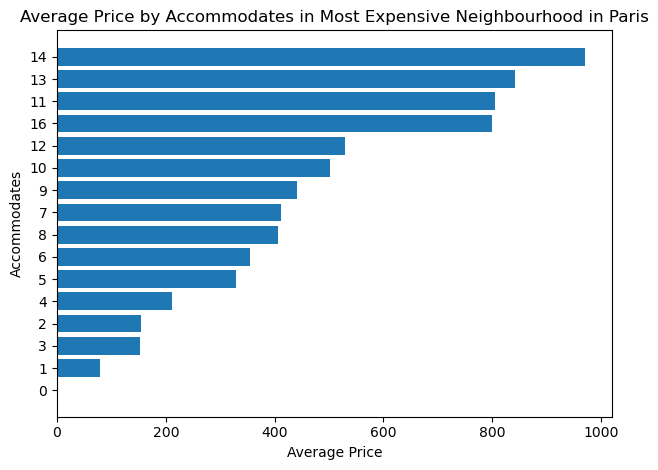

In [89]:
fig, ax = plt.subplots()
ax.barh(paris_listings_accomodations['accommodates'].astype(str), paris_listings_accomodations['average_price'])
ax.set_xlabel('Average Price')
ax.set_ylabel('Accommodates')
ax.set_title('Average Price by Accommodates in Most Expensive Neighbourhood in Paris')
plt.tight_layout()
plt.show()

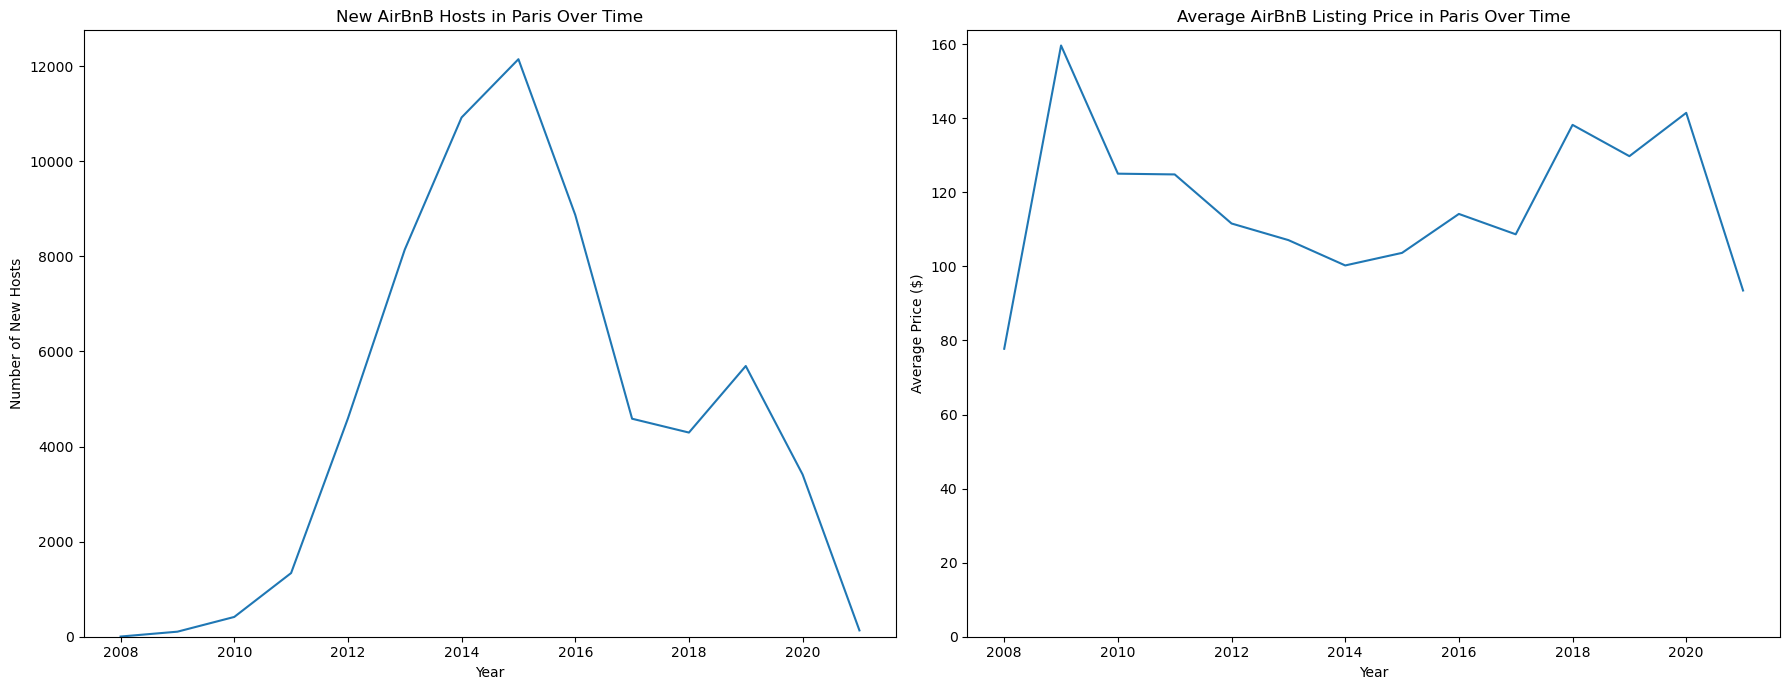

In [93]:
fig, ax = plt.subplots(ncols = 2, figsize=(18, 7))
ax[0].plot(paris_listings_over_time['hosts_count'])
ax[0].set_ylim(bottom=0)
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of New Hosts')
ax[0].set_title('New AirBnB Hosts in Paris Over Time')

ax[1].plot(paris_listings_over_time['average_price'])
ax[1].set_ylim(bottom=0)
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Average Price ($)')
ax[1].set_title('Average AirBnB Listing Price in Paris Over Time')

plt.tight_layout()
plt.show()


INSIGHTS ON THE IMPACT OF 2015 REGULATIONS:

In [ ]:
print('''The line chart shows a severe declination in number of new AirBnB hosts and consequently the prices have increased''')

The line chart shows a severe declination in number of new AirBnB hosts and consequently the prices have increased 


Which neighborhood in Paris has the highest average AirBnB listing price?

In [ ]:
print(f"The neighbourhood with the highest average AirBnB listing price is: {most_expensive_neighbourhood}")

The neighbourhood with the highest average AirBnB listing price is: Elysee
